In [41]:
%load_ext autoreload
%autoreload 2
import sys
if "../" not in sys.path:
    sys.path.append("../")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from scipy.special import roots_laguerre
from scipy.integrate import quad
from math import factorial

import signature.tensor_algebra as ta
from signature.ode_integration import *

PALETTE = ["#5C7B55", "#C0714A", "#C9A84C", "#A8C5A0", "#8B5A6B", "#4A5568"]
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=PALETTE)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### A fully path-dependent example where recentering clearly wins: signature matching to a rising target

We combine a quartic running cost $\int_0^T -(X_t-\mu)^4\,dt$ (which creates the **finite radius of convergence** — the $-x^4$ transform has complex zeros) with a **signature-matching terminal** $-w_{\text{term}}\,\|\widehat{\mathbb X}_T-\widehat{\mathbb X}^*\|^2$ that is *genuinely path-dependent*: it matches the time–state cross words $\mathbf{12},\mathbf{21}$ (path integrals such as $\int X\,ds$), not merely functions of $X_T$, so it requires the 2-D time-augmented signature and has no 1-D Markovian reduction.

The crucial choice is the **target**: a **ramp-and-hold** $Y_t$ that rises linearly to $\mu$ on $[0,T/2]$ and stays at $\mu$. A sine target returns to $0$ (its $\int Y\,ds\approx0$), so matching it only pins the path's *shape* and the optimal state oscillates near the origin — *inside* the radius, where recentering coincides with the single expansion (Lemma 3.4) and shows no gain. The ramp-and-hold instead has a large $\int Y\,ds$, so matching its signature forces the controlled state to rise and **stay far from $0$**, past the radius — exactly the regime where the *single* local expansion diverges and **recentering** (Thm 4.3), relocating the base point along each path, stays accurate.

All three controllers run on the **same** Brownian paths with `source=None` (running cost folded via the time letter, terminal $r=p_{\text{sig}}$): the truncation-exact **Monte-Carlo** benchmark, **Riccati without recentering** (`riccati_policy`, one expansion at $\varnothing$), and **Riccati with recentering** (`simulate_with_recentering`).

In [42]:
# ===== Recentering vs. no recentering:  cost  int_0^T -[(X-mu)^2 + (X-mu)^4] dt  =====
from signature import sig_control as sc
import iisignature

dim_rc, trunc_rc = 2, 10                   # honest order: resolves the shuffle-square nonlinearity
T_rc, mu_rc = 0.4, 1.4                     # far target => trajectory rises and stays far (past the radius)
w4_rc = 5.0                               # quartic creates the finite radius (no quadratic here)
n_dw_rc, size_rc = 300, 12                # n_dw fine enough that the explicit Riccati scheme is stable
M_sig_rc = 2
w_term_rc = 5
t_grid_rc = np.linspace(0.0, T_rc, n_dw_rc)
stab_rc = ta.get_shuffle_table(table_trunc=trunc_rc, dim=dim_rc)
e_state_rc = ta.from_word(2, trunc_rc, dim_rc)
e_time_rc  = ta.from_word(1, trunc_rc, dim_rc)
unit_rc    = ta.unit(trunc_rc, dim_rc)

# pure Riccati generator (NO source: recentering needs source=None, so the cost is folded via the
# time letter)   R psi = psi|_1 + 1/2 psi|_22 + 1/2 (psi|_2)^{sh 2}
@jax.jit
def ode_fun_rc(psi, args):
    return psi.proj(1) + psi.proj(22) * 0.5 + ta.shuffle_pow(psi.proj(2), 2, args["shuffle_table"]) * 0.5

step_fun = step_fun_pece


# (3) signature matching, terminal:  -w_term * ||Sig(X)_T - Sig*||^2  (FULLY path-dependent: it
#   matches the time-state cross words 12, 21 = path integrals, not just functions of X_T).
#     = -w_term * sum_v [ (X^v)^2 - 2 Sig*^v X^v ]   over state-involving words v.
#   Target: a RAMP-AND-HOLD rising linearly to mu on [0, T/2] then held at mu. Unlike a sine (which
#   returns to 0, so its time-integral ~ 0), this has a LARGE int Y ds (signature word 21), so
#   matching its signature forces the controlled state to rise and STAY far from the origin -- past
#   the convergence radius created by the quartic. That sustained far excursion is what makes the
#   single local expansion diverge and recentering pay off.
Y_target = mu_rc * np.clip(2.0 * t_grid_rc / T_rc, 0.0, 1.0)
Sig_star = ta.path_to_signature(jnp.asarray(np.column_stack([t_grid_rc, Y_target])),
                                trunc_rc, only_terminal_sig=True)
p_sig = ta.zero(trunc_rc, dim_rc)
for idx in range(1, ta.number_of_words_up_to_trunc(dim=dim_rc, trunc=M_sig_rc)):
    word = int(ta.index_to_word(idx, dim_rc))
    if "2" in str(word):                       # keep only state-involving (non-constant) words
        v = ta.from_word(word, trunc_rc, dim_rc)
        p_sig = p_sig + ta.shuffle_pow(v, 2, stab_rc) - v * (2.0 * float(Sig_star.array[idx]))
p_sig = p_sig * (-w_term_rc)



# running cost  -w2 (X-mu)^2 - w4 (X-mu)^4  as a signature functional (X = <2, Sig>), folded into a
# terminal functional through the time letter:  p = q (x) e_time   (=> r = 0).
Z_rc = e_state_rc - unit_rc * mu_rc
q_rc = ta.shuffle_pow(Z_rc, 4, stab_rc) * (-w4_rc)
r_rc = p_sig
p_rc = ta.tensor_prod(q_rc, e_time_rc) + r_rc

args_rc = {"shuffle_table": stab_rc, "source": None}
psi_rc = ode_solver_traj(fun=ode_fun_rc, step_fun=step_fun, t_grid=t_grid_rc, init=p_rc, args=args_rc)
print("centered Riccati finite on [0, T]:", bool(np.isfinite(np.asarray(psi_rc.array)).all()))

centered Riccati finite on [0, T]: True


In [43]:
# same Brownian increments for all three controllers
rng_rc = np.random.default_rng(42)
W_rc = np.zeros((size_rc, n_dw_rc))
W_rc[:, 1:] = np.cumsum(rng_rc.normal(size=(size_rc, n_dw_rc - 1)) * np.sqrt(T_rc / (n_dw_rc - 1)), axis=1)
dW_rc = np.diff(W_rc, axis=1)

# truncation-exact Monte-Carlo benchmark sample
p_deg_rc = int(p_rc.get_lengths_array()[np.abs(np.array(p_rc.array)) > 1e-12].max())
N_MC_rc, n_fine_rc = 500_000, 80
rng_mc_rc = np.random.default_rng(1)
u_rc = np.linspace(0.0, 1.0, n_fine_rc)
W1_rc = np.cumsum(rng_mc_rc.normal(size=(N_MC_rc, n_fine_rc - 1)) * np.sqrt(1.0 / (n_fine_rc - 1)), axis=1)
paths_rc = np.zeros((N_MC_rc, n_fine_rc, dim_rc))
paths_rc[:, 1:, 0] = u_rc[1:][None, :]
paths_rc[:, 1:, 1] = W1_rc
SigW1_rc = ta.from_array(jnp.asarray(np.vstack([np.ones((1, N_MC_rc)), iisignature.sig(paths_rc, p_deg_rc).T])),
                         trunc=p_deg_rc, dim=dim_rc)

In [48]:
# three controllers on the SAME Brownian paths (recentering re-solves only crossing columns; with a
# far, sustained target it crosses often -- expect a minute or so at n_dw=300).
riccati_data_rc = dict(ode_fun=ode_fun_rc, step_fun=step_fun, t_grid=t_grid_rc, r=p_rc,
                       shuffle_table=stab_rc, source=None, state_letter=2)
x0 = 0
eps_recentering = 0.01
runs_rc = {
    "Riccati (no recentering)": sc.simulate(dW_rc, t_grid_rc, sc.riccati_policy(psi_rc, state_letter=2), trunc_rc, dim_rc, x0=x0),
    "Riccati (recentering)":    sc.simulate_with_recentering(dW_rc, t_grid_rc, riccati_data_rc, trunc_rc, dim=dim_rc, x0=x0, recenter_threshold=1 - eps_recentering / 2),
    "Monte-Carlo":              sc.simulate(dW_rc, t_grid_rc, sc.monte_carlo_policy(p_rc, SigW1_rc, T_rc, trunc_rc, dim_rc), trunc_rc, dim_rc, x0=x0),
}

# Per-trajectory control error vs the Monte-Carlo benchmark. Recentering can overflow (NaN) on the
# very farthest paths -- there the recentered terminal {}_X|p has huge coefficients (the quartic's
# 4!*w4 factor) that the explicit trunc-10 scheme cannot integrate; this is a numerical limit, not a
# failure of Thm 3.3. So we report robustly and count the finite paths.
ref_rc = runs_rc["Monte-Carlo"]
a_err = {name: np.max(np.abs(run.control[:, :-1] - ref_rc.control[:, :-1]), axis=1) for name, run in runs_rc.items()}
print("%-26s %9s %16s %16s" % ("controller", "nt_max", "median|a-a_MC|", "max finite|a-a_MC|"))
for name, run in runs_rc.items():
    nt = np.nanmax(run.extra["norm_tracker"][:, :-1]) if "norm_tracker" in run.extra else np.nan
    a = a_err[name]; fin = np.isfinite(a)
    print("%-26s %9.1f %16.3f %16.3f   (%d/%d paths finite)"
          % (name, nt, np.median(a[fin]), a[fin].max(), int(fin.sum()), len(a)))

controller                    nt_max   median|a-a_MC| max finite|a-a_MC|
Riccati (no recentering)       132.5            3.409           36.521   (12/12 paths finite)
Riccati (recentering)            1.0            0.128            0.162   (8/12 paths finite)
Monte-Carlo                      nan            0.000            0.000   (12/12 paths finite)


In [53]:
show

array([ 7, 11, 10])

displayed trajectories: [7, 10]  no-recentering err = [36.5  5.2]  recentering err = [0.156 0.111]


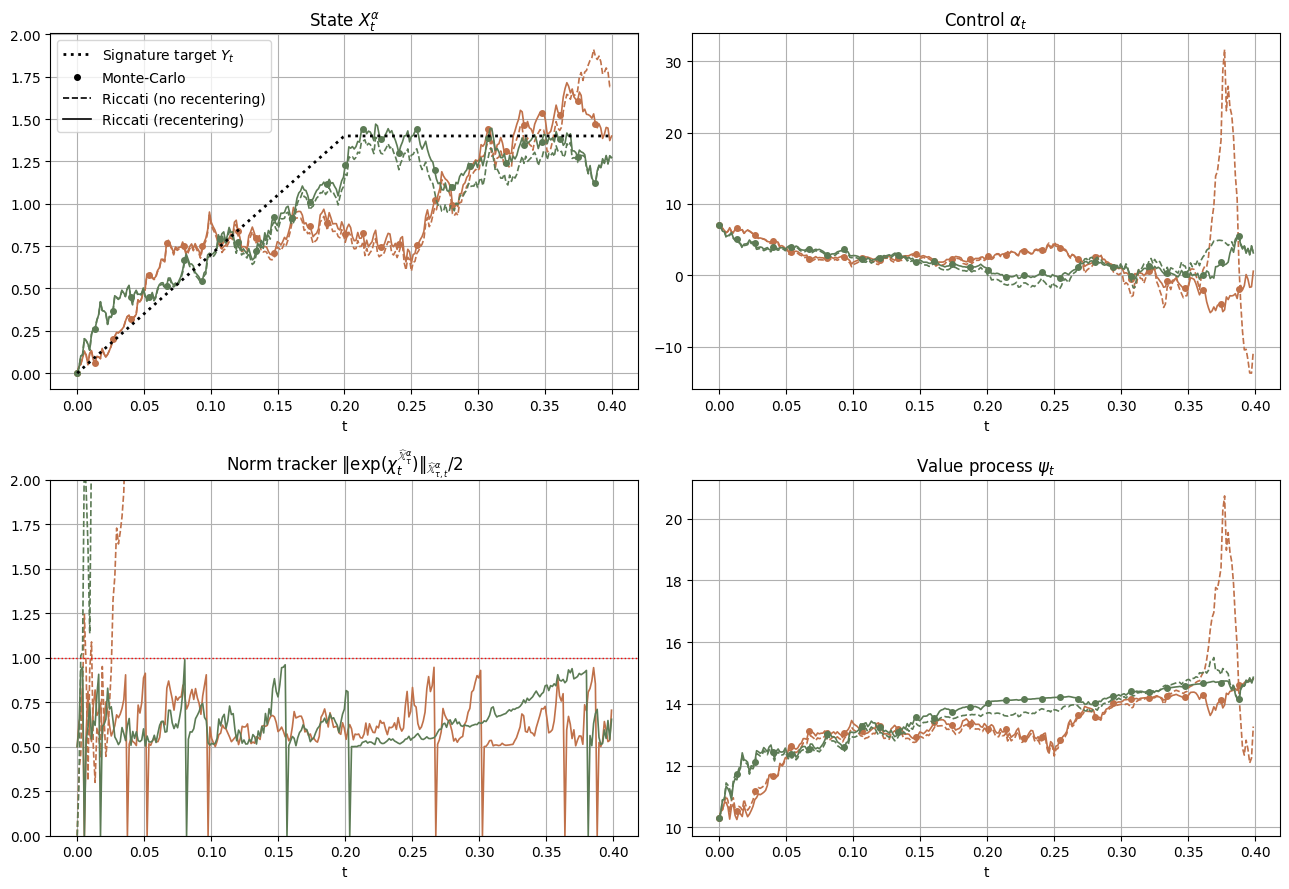

In [84]:
# Show the trajectories where recentering is finite and the single expansion diverges most: for these
# the no-recentering control blows up by 1-2 orders of magnitude while recentering tracks Monte-Carlo.
a_no_rc, a_re_rc = a_err["Riccati (no recentering)"], a_err["Riccati (recentering)"]
ok = np.where(np.isfinite(a_re_rc))[0]
show = ok[np.argsort(a_no_rc[ok])[::-1]][:3]
show = [7, 10]
print("displayed trajectories:", show, " no-recentering err =", np.round(a_no_rc[show], 1),
      " recentering err =", np.round(a_re_rc[show], 3))

PAL_rc = ["#C0714A", "#5C7B55", "#8B5A6B"]
sty_rc = {"Monte-Carlo":              dict(ls="none", marker="o", ms=4, markevery=10),
          "Riccati (no recentering)": dict(ls="--", lw=1.2),
          "Riccati (recentering)":    dict(ls="-",  lw=1.2)}
fig, ax = plt.subplots(2, 2, figsize=(13, 9)); ax = ax.ravel()   # [[State, Control], [Value, Norm tracker]]
for j, k in enumerate(show):
    for name, run in runs_rc.items():
        s = sty_rc[name]
        ax[0].plot(t_grid_rc, run.X[k], color=PAL_rc[j], **s)
        ax[1].plot(t_grid_rc[:-1], run.control[k, :-1], color=PAL_rc[j], **s)
        ax[3].plot(t_grid_rc[:-1], run.value[k, :-1], color=PAL_rc[j], **s)
        if name != "Monte-Carlo":
            ax[2].plot(t_grid_rc[:-1], run.extra["norm_tracker"][k, :-1], color=PAL_rc[j], **s)
ax[0].plot(t_grid_rc, mu_rc * np.clip(2.0 * t_grid_rc / T_rc, 0.0, 1.0), "k:", lw=2, label=r"Signature target $Y_t$")
ax[2].axhline(1.0, color="r", ls=":", lw=1); ax[2].set_ylim(0, 2)
for name, s in sty_rc.items():
    ax[0].plot([], [], color="k", **s, label=name)
ax[0].legend(loc="best")
ax[0].set_title(r"State $X^\alpha_t$")
ax[1].set_title(r"Control $\alpha_t$")
ax[3].set_title(r"Value process $\psi_t$")
ax[2].set_title(r"Norm tracker $\|\exp(\chi_t^{\widehat{\mathbb{X}}_{\tau}^\alpha})\|_{\widehat{\mathbb{X}}_{\tau, t}^\alpha} / 2$")
for a in ax:
    a.set_xlabel("t")
fig.tight_layout()
fig.savefig("images/sig-control/example_mu_const.pdf", format="pdf", transparent=True)

In [85]:
# --- save the three Brownian increment paths displayed above, to reuse on the moving-target problem ---
import os
show_idx = np.asarray(show)                      # the 3 trajectory indices shown in the figure
dW_saved = np.asarray(dW_rc[show_idx]).copy()    # (3, n_dw-1) Brownian increments
W_saved  = np.asarray(W_rc[show_idx]).copy()     # (3, n_dw)   Brownian paths
os.makedirs("data", exist_ok=True)
np.save("data/ramp_hold_dW_saved.npy", dW_saved)
print("saved", dW_saved.shape[0], "Brownian paths (indices", show_idx.tolist(),
      ") to data/ramp_hold_dW_saved.npy")

saved 2 Brownian paths (indices [7, 10] ) to data/ramp_hold_dW_saved.npy


### Time-dependent target: a recentered time-dependent source

We keep exactly the cost of the example above — the quartic running cost **plus** the signature-matching terminal — but make the running-cost target **time-dependent**: $\mu(t)=2\sqrt t$, while the signature-matching terminal still targets the ramp-and-hold $Y_t$. The running cost becomes
$$q_t=-w_4\,(\mathbf 2-\mu(t))^{\text{ш}4},\qquad \mu(t)=2\sqrt t,$$
a **time-dependent** source which (being time-dependent) cannot be folded into the terminal through the time letter. So `simulate_with_recentering` recenters the source: at each recentering it shifts **both** the terminal $r=r_{\rm rc}$ *and every time-slice* of $q$ by the running signature,
$$\{}_{\mathbb X}\!\mid q_s=\sum_w \mathbb X^w\, q_s\!\mid^{w},$$
recomputing a per-path shifted-source trajectory for the crossing paths. Since $q$ has degree $4$ it is stored at truncation $4$ ($31$ coefficients) and paired against the order-$10$ signature on its first $31$ coefficients (the word$\to$index map is truncation-independent, so this is exact).

We solve on the **same three Brownian paths saved above** and keep the other parameters ($w_4=5$, $w_{\rm term}=5$, $T=0.4$, $n_{dw}=300$, $\text{trunc}=10$). The benchmark is `monte_carlo_source_policy` (Monte-Carlo for a time-dependent running cost).

In [ ]:
# ===== Moving target: running cost  int_0^T -(X_t - mu(t))^4 dt  with  mu(t) = 2 sqrt(t),
#       plus the signature-matching terminal r_rc (matching the ramp-and-hold Y of the example above). =====
deg_q = 4
stab_q = ta.get_shuffle_table(table_trunc=deg_q, dim=dim_rc)
e_state_q, unit_q = ta.from_word(2, deg_q, dim_rc), ta.unit(deg_q, dim_rc)
mu_run = lambda c: 2.0 * np.sqrt(np.clip(c, 0.0, None))            # time-dependent running-cost target mu(t)=2 sqrt(t)
Yt     = lambda c: mu_rc * np.clip(2.0 * c / T_rc, 0.0, 1.0)       # ramp-and-hold target (the one matched by r_rc)

# time-dependent running cost  q_t = -w4 (X - mu(t))^{sh4}, kept at truncation 4 (31 coeffs). Column i is
# q at the solver's reversed-time step i = calendar time T - t_grid[i] (same convention as riccati_policy).
q_traj = ta.from_array(jnp.stack([(ta.shuffle_pow(e_state_q - unit_q * mu_run(T_rc - t_grid_rc[i]), 4, stab_q)
                                   * (-w4_rc)).array for i in range(n_dw_rc)], axis=1), deg_q, dim_rc)
r_mt = r_rc                                                       # keep the signature-matching terminal (ramp-and-hold Y)
riccati_data_mt = dict(ode_fun=ode_fun_rc, step_fun=step_fun, t_grid=t_grid_rc, r=r_mt,
                       source=q_traj, shuffle_table=stab_rc, state_letter=2)

dW_mt = dW_saved                                                  # the 3 saved Brownian paths
# Riccati WITH recentering, and the single-expansion Riccati benchmark WITHOUT it
# (recenter_threshold=inf => never recenters), on the same paths.
run_mt    = sc.simulate_with_recentering(dW_mt, t_grid_rc, riccati_data_mt, trunc_rc, dim=dim_rc, recenter_threshold=1 - eps_recentering / 2)
run_no_mt = sc.simulate_with_recentering(dW_mt, t_grid_rc, riccati_data_mt, trunc_rc, dim=dim_rc, recenter_threshold=np.inf)

# Monte-Carlo benchmark for the time-dependent running cost + signature-matching terminal
deg_mt = max(sc._max_degree(r_mt), sc._max_degree(q_traj))
traj_mt = sc.brownian_signature_trajectory(t_grid_rc, N_MC=100_000, trunc_mc=deg_mt, dim=dim_rc, seed=7)
run_mc_mt = sc.simulate(dW_mt, t_grid_rc, sc.monte_carlo_source_policy(r_mt, q_traj, traj_mt, t_grid_rc, dim=dim_rc),
                        trunc_rc, dim_rc)

err = lambda run: [round(float(np.max(np.abs(run.control[k, :-1] - run_mc_mt.control[k, :-1]))), 3) for k in range(dW_mt.shape[0])]
print("norm-tracker max:  recentering = %.2f   no recentering = %.1f"
      % (np.nanmax(run_mt.extra["norm_tracker"][:, :-1]), np.nanmax(run_no_mt.extra["norm_tracker"][:, :-1])))
print("control error vs Monte-Carlo (per path):  recentering =", err(run_mt), "  no recentering =", err(run_no_mt))

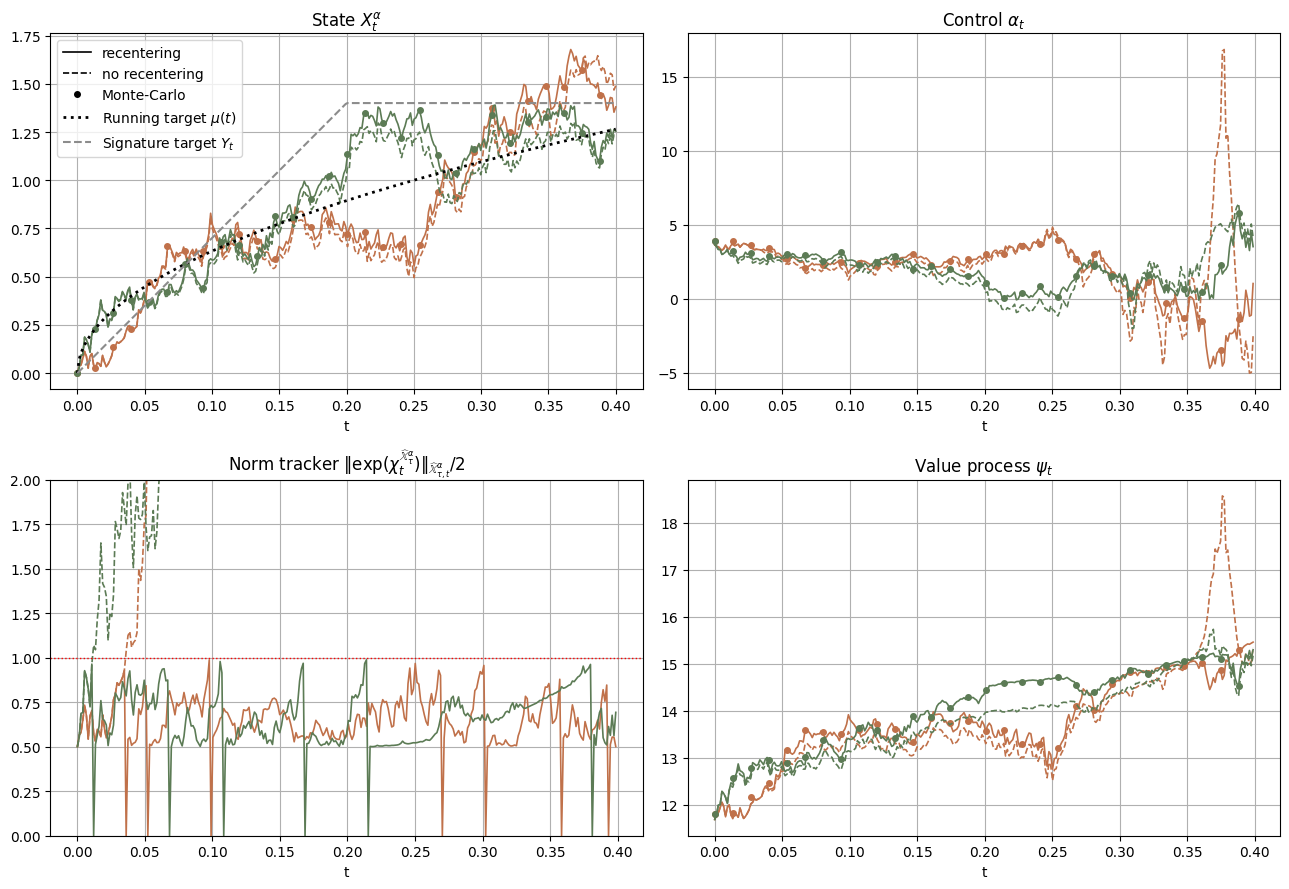

In [87]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9)); ax = ax.ravel()
PAL_mt = ["#C0714A", "#5C7B55", "#8B5A6B"]
mark = dict(ls="none", marker="o", ms=4, markevery=10)
solid, dash = dict(ls="-", lw=1.2), dict(ls="--", lw=1.2)
for k in range(dW_mt.shape[0]):
    col = PAL_mt[k]
    ax[0].plot(t_grid_rc, run_mt.X[k], color=col, **solid)
    ax[0].plot(t_grid_rc, run_no_mt.X[k], color=col, **dash)
    ax[0].plot(t_grid_rc, run_mc_mt.X[k], color=col, **mark)
    ax[1].plot(t_grid_rc[:-1], run_mt.control[k, :-1], color=col, **solid)
    ax[1].plot(t_grid_rc[:-1], run_no_mt.control[k, :-1], color=col, **dash)
    ax[1].plot(t_grid_rc[:-1], run_mc_mt.control[k, :-1], color=col, **mark)
    ax[3].plot(t_grid_rc[:-1], run_mt.value[k, :-1], color=col, **solid)
    ax[3].plot(t_grid_rc[:-1], run_no_mt.value[k, :-1], color=col, **dash)
    ax[3].plot(t_grid_rc[:-1], run_mc_mt.value[k, :-1], color=col, **mark)
    ax[2].plot(t_grid_rc[:-1], run_mt.extra["norm_tracker"][k, :-1], color=col, **solid)
    ax[2].plot(t_grid_rc[:-1], run_no_mt.extra["norm_tracker"][k, :-1], color=col, **dash)
ax[0].plot(t_grid_rc, mu_run(t_grid_rc), "k:", lw=2)                  # running-cost target mu(t)=2 sqrt(t)
ax[0].plot(t_grid_rc, Yt(t_grid_rc), color="0.55", ls="--", lw=1.5)   # signature-matching target Y_t (ramp-and-hold)
ax[2].axhline(1.0, color="r", ls=":", lw=1)
ax[2].set_ylim(0, 2)
for lab, st in [("recentering", solid), ("no recentering", dash)]:
    ax[0].plot([], [], color="k", label=lab, **st)
ax[0].plot([], [], color="k", **mark, label="Monte-Carlo")
ax[0].plot([], [], "k:", lw=2, label=r"Running target $\mu(t)$")
ax[0].plot([], [], color="0.55", ls="--", lw=1.5, label=r"Signature target $Y_t$")
ax[0].legend(loc="best")
ax[0].set_title(r"State $X^\alpha_t$ ")
ax[1].set_title(r"Control $\alpha_t$"); 
ax[3].set_title(r"Value process $\psi_t$")
ax[2].set_title(r"Norm tracker $\|\exp(\chi_t^{\widehat{\mathbb{X}}_{\tau}^\alpha})\|_{\widehat{\mathbb{X}}_{\tau, t}^\alpha} / 2$")
for a in ax: a.set_xlabel("t")
fig.tight_layout()
fig.savefig("images/sig-control/example_mu_timedep.pdf", format="pdf", transparent=True)